# Worked Example of the Grid World Problem

Problem describes a 2 by 2 square with four co-ordinates. The top left square (TL), the top right (TR), bottom left (BL) and bottom right (BR). Actions are to move around this state space with moves right (R), left (L), down (D) and up (U). There is a reward for each move to each square except from the bottom right (BR) as this is the terminating square. 
In doing each action move there is also with some probabilty the chance of moving to a differnt intended square. For example, can move from top left (TL) to top right (TR) with 90% chance by moving right (R) but may end up in the bottom left (BL) square with 10% probability.

| State (s) | Action (a) | Next State (s') | Probability |
|-----------|------------|----------------|------------|
| TL        | R          | TR             | 0.9        |
| TL        | R          | BL             | 0.1        |
| TL        | D          | BL             | 0.9        |
| TL        | D          | TR             | 0.1        |
| TR        | L          | TL             | 0.9        |
| TR        | L          | BR             | 0.1        |
| TR        | D          | BR             | 0.8        |
| TR        | D          | TL             | 0.2        |
| BL        | R          | BR             | 0.9        |
| BL        | R          | TL             | 0.1        |
| BL        | U          | TL             | 0.8        |
| BL        | U          | BR             | 0.2        |
| BR        | U          | BR             | 1.0        |
| BR        | D          | BR             | 1.0        |
| BR        | R          | BR             | 1.0        |
| BR        | L          | BR             | 1.0        |


| State (s) | Action (a) | Next State (s') | Reward |
|-----------|------------|----------------|--------|
| TL        | R          | TR             | -1.0   |
| TL        | R          | BL             | -2.0   |
| TL        | D          | BL             | -2.0   |
| TL        | D          | TR             | -1.0   |
| TR        | L          | TL             | -1.5   |
| TR        | L          | BR             | 10.0   |
| TR        | D          | BR             | 15.0   |
| TR        | D          | TL             | -1.0   |
| BL        | R          | BR             | 20.0   |
| BL        | R          | TL             | -2.5   |
| BL        | U          | TL             | -0.5   |
| BL        | U          | BR             | 5.0    |



In [1]:
from VIA import value_iteration

### Using value iteration algorithm

The value iteration algorithm uses bellman ford equation to solve to find the maximium value policy of actions and states. For more detail of how it works see Artificial Intelligence: Foundations and Computational Agents 2nd edition (https://artint.info/2e/html2e/ArtInt2e.html)

After implementing the algorithm we need only to define the state and action space of the Grid World Problem.

In [2]:
def grid_world_mdp():
    #Define states and actions
    states = ['TL', 'TR', 'BL', 'BR']
    actions = ['R', 'L', 'U', 'D']
    
    P_dict = {
        'TL': {'R': {'TR': 0.9, 'BL': 0.1},
               'D': {'BL': 0.9, 'TR': 0.1}},
        'TR': {'L': {'TL': 0.9, 'BR': 0.1},
               'D': {'BR': 0.8, 'TL': 0.2}},
        'BL': {'R': {'BR': 0.9, 'TL': 0.1},
               'U': {'TL': 0.8, 'BR': 0.2}},
        'BR': {}
        }
    
    # R[(s, a, s_next)] = reward for that transition
    R_dict = {
        ('TL', 'R', 'TR'): -1,
        ('TL', 'R', 'BL'): -2,
        ('TL', 'D', 'BL'): -2,
        ('TL', 'D', 'TR'): -1,
        ('TR', 'L', 'TL'): -3/2,
        ('TR', 'L', 'BR'): 10,
        ('TR', 'D', 'BR'): 15,
        ('TR', 'D', 'TL'): -1,
        ('BL', 'R', 'BR'): 20,
        ('BL', 'R', 'TL'): -5/2,
        ('BL', 'U', 'TL'): -1/2,
        ('BL', 'U', 'BR'): 5,
        }
    
    def P(s, a, s_next):
        return P_dict.get(s, {}).get(a, {}).get(s_next, 0)

    def R(s, a, s_next):
        return R_dict.get((s, a, s_next), 0)
        
    
    gamma = 0.9
    epsilon = 1e-6

    policy, value_function, delta_list = value_iteration(states, actions, P, R, gamma, epsilon)
    return policy, value_function, delta_list

### Running Algorithm

We can now run the alogirthm to find the best policy:

In [3]:
if __name__ == "__main__":
    #only run if script run directly (not imported)
    policy, value_function, delta_list = grid_world_mdp()
    print("Optimal Policy:", policy)
    print("Value Function:", value_function)

Optimal Policy: {'TL': 'D', 'TR': 'D', 'BL': 'R', 'BR': None}
Value Function: {'TL': 14.863870837874162, 'TR': 14.47549675081735, 'BL': 19.087748375408676, 'BR': 0}


### Results

We see that the optimal policy found was:
- If in state top left move down.
- If in state top right move down.
- If in state bottom left move right.
- If in state bottom left take no action as it is terminating state.
See plots below for demonstationof the valu of each square, the policy and the convergence of the value iterated algorithm.

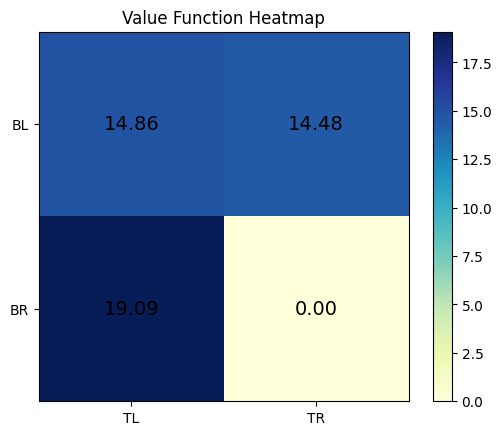

In [4]:
import matplotlib.pyplot as plt
import numpy as np

V = value_function

# Arrange values into a 2x2 grid (row-major)
values = np.array([[V['TL'], V['TR']],
                   [V['BL'], V['BR']]])

fig, ax = plt.subplots()

# Create heatmap using imshow
cax = ax.imshow(values, cmap='YlGnBu', interpolation='nearest')

# Annotate each cell with the value
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        ax.text(j, i, f"{values[i, j]:.2f}", ha='center', va='center', color='black', fontsize=14)

# Add colorbar
fig.colorbar(cax)

# Remove ticks and label axes
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['TL','TR'])
ax.set_yticklabels(['BL','BR'])
ax.set_title("Value Function Heatmap")

plt.show()

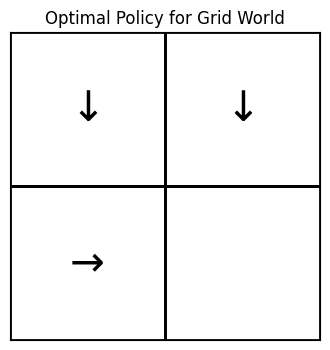

In [5]:
import matplotlib.pyplot as plt

# Map actions to arrow directions
arrow_map = {'U':'↑', 'D':'↓', 'L':'←', 'R':'→', None:''}

# 2x2 grid layout
states = [['TL', 'TR'],
          ['BL', 'BR']]

fig, ax = plt.subplots(figsize=(4,4))

# Draw grid
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1-i), 1, 1, fill=False, edgecolor='black', linewidth=2))

# Put arrows for policy
for i in range(2):
    for j in range(2):
        s = states[i][j]
        action = policy[s]
        ax.text(j+0.5, 1-i+0.5, arrow_map[action], ha='center', va='center', fontsize=30)

# Set limits and remove ticks
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Optimal Policy for Grid World")
plt.show()

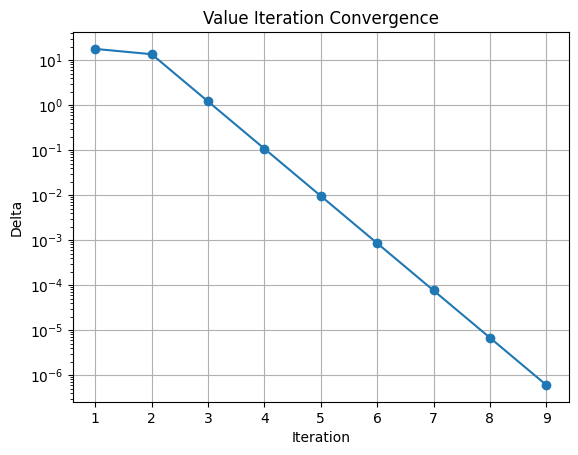

In [6]:
# Plot convergence
import matplotlib.pyplot as plt

plt.plot(range(1, len(delta_list)+1), delta_list, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Delta")
plt.title("Value Iteration Convergence")
plt.yscale("log")  
plt.grid(True)
plt.show()